### Simulated Tempering Implementation


Simulated Tempering (ST) belongs to the tempering family together with Parallel Tempering (PT).

**Plan in this notebook**

1. Run an **SMC sampler** to build a tempering ladder $\{\lambda_t\}$ and estimates of intermediate normalizing constants $\{\log Z_t\}$.
2. Define the ST targets
   $$
   \pi_t(x)=\frac{1}{Z_t}\,\tilde\pi_{\lambda_t}(x),\qquad
   \tilde\pi_{\lambda}(x)=\pi_0(x)^{1-\lambda}\pi_1(x)^{\lambda}.
   $$
   With a uniform temperature prior, each ladder level is visited roughly equally often.
3. Transition $(t,x)\to(t',x')$ in two Metropolis–Hastings substeps:
   - **Explore:** $x'=x+\mathcal N(0,\sigma^2 I)$ at fixed $t$.
   - **Jump:** propose $t'\in\{t-1,t+1\}$ (boundary-aware proposal $q$), keep $x$ fixed.
4. Collect samples only when the chain is at the **cold** level $t=T$ ($\lambda_T=1$).

Compare later with SMC and Parallel Tempering on the same targets.


In [18]:
from pathlib import Path
import runpy

for _root in [Path.cwd(), *Path.cwd().parents]:
    _setup = _root / "setup_path.py"
    if _setup.is_file():
        runpy.run_path(str(_setup), run_name="__setup_path__")
        break

from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import lax, random, vmap
from jax.scipy.stats import norm

from libs import SMC


### State and ST sampler

State is the pair `(t_idx, x)` where `t_idx` indexes the SMC ladder
`lambda_path[t_idx]` with matching `log_z_path[t_idx]`.


In [ ]:

@dataclass
class TemperingState:
    """ST Markov state: ladder index + configuration."""
    t_idx: int
    x: jnp.ndarray


class SimulatedTempering:
    """Simulated Tempering on an SMC tempering ladder.

    Joint target (uniform temperature prior):
        pi(t, x) propto pi_t(x) = tilde_pi_{lambda_t}(x) / Z_t

    Moves
    -----
    explore : x' = x + N(0, step_size^2 I), MH at fixed t
    jump    : t' in {t-1, t+1} (boundary-aware proposal q)

    Sampling
    --------
    `run` draws many independent (x0, key) pairs and `vmap`s `run_excursion`.
    """

    def __init__(
        self,
        smc: SMC,
        lambda_path,
        log_z_path,
        step_size: float = 0.1,
        seed: int = 0,
        dims: int = 1,
        max_cold_keep: int = 64,
    ):
        self.smc = smc
        self.lambda_path = jnp.asarray(lambda_path, dtype=float)
        self.log_z_path = jnp.asarray(log_z_path, dtype=float)
        if self.lambda_path.shape != self.log_z_path.shape:
            raise ValueError("lambda_path and log_z_path must have the same length")
        if int(self.lambda_path.shape[0]) < 2:
            raise ValueError("need at least 2 ladder levels")
        self.n_levels = int(self.lambda_path.shape[0])
        self.t_cold = self.n_levels - 1
        self.t_hot = 0
        self.step_size = float(step_size)
        self.dims = int(dims)
        self.max_cold_keep = int(max_cold_keep)
        self._key = random.key(seed)

    def log_pi_t(self, t_idx, x):
        """log pi_t(x) = log tilde_pi_lambda(x) - log Z_t."""
        lam = self.lambda_path[t_idx]
        log_z = self.log_z_path[t_idx]
        return self.smc.get_intermediate_logpdf(x, lam) - log_z

    def explore(self, t_idx, x, key):
        key, k_prop, k_u = random.split(key, 3)
        x_prop = x + self.step_size * random.normal(k_prop, shape=x.shape)
        log_alpha = self.log_pi_t(t_idx, x_prop) - self.log_pi_t(t_idx, x)
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        return jnp.where(accept, x_prop, x), key

    def jump(self, t_idx, x, key):
        key, k_dir, k_u = random.split(key, 3)
        T = self.n_levels - 1
        u = random.uniform(k_dir)
        t_prop = jnp.where(
            t_idx == 0,
            1,
            jnp.where(t_idx == T, T - 1, jnp.where(u < 0.5, t_idx - 1, t_idx + 1)),
        )
        q_fwd = jnp.where((t_idx == 0) | (t_idx == T), 1.0, 0.5)
        q_rev = jnp.where((t_prop == 0) | (t_prop == T), 1.0, 0.5)
        log_alpha = (
            self.log_pi_t(t_prop, x) - self.log_pi_t(t_idx, x)
            + jnp.log(q_rev) - jnp.log(q_fwd)
        )
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        return jnp.where(accept, t_prop, t_idx), key

    def move(self, t_idx, x, key):
        x, key = self.explore(t_idx, x, key)
        t_idx, key = self.jump(t_idx, x, key)
        return t_idx, x, key

    def run_excursion(self, x0, key, max_steps: int = 2_000):
        """One excursion with explicit PRNG key (vmap-friendly).

        Starts at hot t=0, stops after leaving hot and returning to hot
        (or when max_steps is hit).

        Returns
        -------
        cold_buf : (max_cold_keep, d) stored cold-level states
        cold_n : int number of stored cold states
        n_steps : int live moves performed
        visit_counts : (n_levels,) live visit histogram
        """
        x0 = jnp.asarray(x0, dtype=float).reshape((self.dims,))
        cold_buf0 = jnp.zeros((self.max_cold_keep, self.dims), dtype=x0.dtype)
        visits0 = jnp.zeros((self.n_levels,), dtype=jnp.int32)

        def scan_step(carry, _):
            t_idx, x, key, left_hot, done, cold_buf, cold_n, visits = carry
            key, k_move = random.split(key)

            def do_move(_):
                t_new, x_new, key_new = self.move(t_idx, x, k_move)
                left_new = left_hot | (t_new != self.t_hot)
                done_new = left_new & (t_new == self.t_hot)
                return t_new, x_new, key_new, left_new, done_new

            def stay(_):
                return t_idx, x, key, left_hot, done

            t_new, x_new, key_new, left_new, done_new = lax.cond(
                done, stay, do_move, operand=None
            )
            was_live = ~done
            visits_new = visits.at[t_new].add(was_live.astype(jnp.int32))

            store = was_live & (t_new == self.t_cold) & (cold_n < self.max_cold_keep)
            cold_buf_new = jnp.where(
                store,
                cold_buf.at[cold_n].set(x_new),
                cold_buf,
            )
            cold_n_new = cold_n + store.astype(jnp.int32)

            new_carry = (
                t_new, x_new, key_new, left_new, done_new,
                cold_buf_new, cold_n_new, visits_new,
            )
            return new_carry, was_live

        init = (
            jnp.asarray(self.t_hot, dtype=jnp.int32),
            x0,
            key,
            jnp.asarray(False),
            jnp.asarray(False),
            cold_buf0,
            jnp.asarray(0, dtype=jnp.int32),
            visits0,
        )
        (t_f, x_f, key_f, left_f, done_f, cold_buf, cold_n, visits), live = lax.scan(
            scan_step, init, xs=None, length=max_steps
        )
        n_steps = jnp.sum(live.astype(jnp.int32))
        return cold_buf, cold_n, n_steps, visits

    def run(
        self,
        n_excursions: int = 100_000,
        max_steps: int = 2_000,
        key=None,
    ):
        """Generate all x0's and keys, then vmap run_excursion over them.

        Returns
        -------
        cold_samples : (n_cold, d) pooled cold states
        n_steps : (n_excursions,)
        visit_counts : (n_levels,)
        """
        if key is None:
            self._key, key = random.split(self._key)

        key, k_x0, k_exc = random.split(key, 3)
        x0s = random.normal(k_x0, shape=(n_excursions, self.dims))
        keys = random.split(k_exc, n_excursions)

        cold_buf, cold_n, n_steps, visits = vmap(
            lambda x0, k: self.run_excursion(x0, k, max_steps=max_steps)
        )(x0s, keys)

        # Pool variable-length cold buffers
        # cold_buf: (E, K, d), cold_n: (E,)
        ids = jnp.arange(self.max_cold_keep)[None, :]
        mask = ids < cold_n[:, None]
        cold_samples = cold_buf[mask]
        visit_counts = jnp.sum(visits, axis=0)
        return cold_samples, n_steps, visit_counts


### Demo: 1-D Gaussian mixture

Target $\pi_1$ is a bimodal mixture; base $\pi_0$ is standard normal (SMC default prior).
We first build $\{\lambda_t,\log Z_t\}$ with SMC, then run ST on that ladder.


In [20]:
def mixture_logpdf(x):
    """log (0.5 N(-2,1) + 0.5 N(2,1)); supports scalar or SMC batch (n,) / (n,1)."""
    x = jnp.asarray(x)
    if x.ndim >= 1 and x.shape[-1] == 1:
        x = x[..., 0]
    return jnp.logaddexp(
        norm.logpdf(x, loc=-5.0, scale=1.0),
        norm.logpdf(x, loc=5.0, scale=1.0),
    ) - jnp.log(2.0)

Plot the pdf to show how it looks 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_11237/4159264753.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


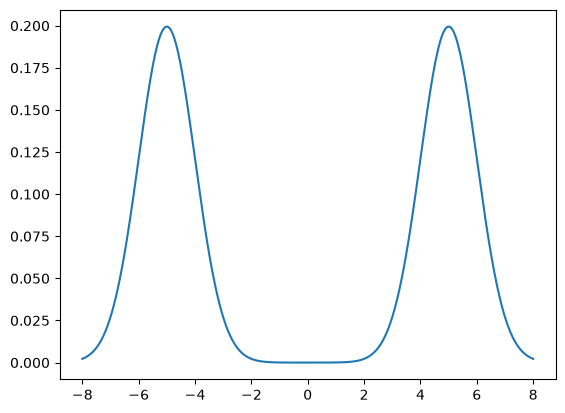

In [21]:
from matplotlib import pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()
xx = np.linspace(-8, 8, 1000) 
yy = np.exp(mixture_logpdf(xx))

ax.plot(xx, yy)
fig.show()

In [22]:
# --- Stage 1: SMC ladder + Z_t ---
N_SMC = 2_000
smc = SMC(dims=1, target_dist_logpdf=mixture_logpdf, key=random.key(0))
smc.reset(no_samples=N_SMC)
lambda_path, log_z_path, tot_log_z = smc.build_intermediate_dists(
    mcmc_iters=10, verbose=True
)

print(f"ladder size = {len(lambda_path)}")
print(f"lambda_path = {[round(float(l), 4) for l in lambda_path]}")
print(f"log_z_path  = {[round(float(z), 4) for z in log_z_path]}")
print(f"tot log Z   = {float(tot_log_z):.4f}")


[SMC] step 0: lambda=0.0 -> 0.1422218233346939, diff_log_z=-1.1683144569396973
[SMC] step 1: lambda=0.1422218233346939 -> 0.2659308910369873, diff_log_z=-0.8003077507019043
[SMC] step 2: lambda=0.2659308910369873 -> 0.3827378451824188, diff_log_z=-0.5150399208068848
[SMC] step 3: lambda=0.3827378451824188 -> 0.4931175708770752, diff_log_z=-0.21534490585327148
[SMC] step 4: lambda=0.4931175708770752 -> 0.6002053618431091, diff_log_z=0.04938840866088867
[SMC] step 5: lambda=0.6002053618431091 -> 0.7057244777679443, diff_log_z=0.32723045349121094
[SMC] step 6: lambda=0.7057244777679443 -> 0.8129988312721252, diff_log_z=0.6368865966796875
[SMC] step 7: lambda=0.8129988312721252 -> 0.9245262742042542, diff_log_z=0.9332122802734375
[SMC] final step: lambda=0.9245262742042542 -> 1.0
ladder size = 10
lambda_path = [0.0, 0.1422, 0.2659, 0.3827, 0.4931, 0.6002, 0.7057, 0.813, 0.9245, 1.0]
log_z_path  = [0.0, -1.1683, -1.9686, -2.4837, -2.699, -2.6496, -2.3224, -1.6855, -0.7523, 0.0512]
tot log Z

In [ ]:

# --- Stage 2: Simulated Tempering (batched excursions via vmap) ---
st = SimulatedTempering(
    smc=smc,
    lambda_path=lambda_path,
    log_z_path=log_z_path,
    step_size=0.05,
    seed=1,
    dims=1,
    max_cold_keep=64,
)

# 100_000 independent excursions in parallel (each with its own x0 + PRNG key)
cold_samples, n_steps, visit_counts = st.run(
    n_excursions=100_000,
    max_steps=2_000,
    key=random.key(1),
)

print(f"cold samples pooled: {int(cold_samples.shape[0])}")
print(
    f"excursion length mean/median: "
    f"{float(n_steps.mean()):.1f} / {float(jnp.median(n_steps)):.1f}"
)
vc = np.asarray(visit_counts)
print(f"visit counts by level: {vc.tolist()}")
print(f"visit fractions: {(vc / max(vc.sum(), 1)).round(3).tolist()}")
print(f"lambda at levels: {[round(float(l), 3) for l in lambda_path]}")


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# visit histogram
axes[0].bar(np.arange(st.n_levels), np.asarray(visit_counts) / np.asarray(visit_counts).sum())
axes[0].set_xlabel("t_idx")
axes[0].set_ylabel("fraction of time")
axes[0].set_title("Temperature occupancy (live excursion steps)")
axes[0].grid(axis="y", alpha=0.3)

# cold-level histogram vs true mixture density
xs = np.linspace(-8, 8, 1000)
true_dens = 0.5 * (
    np.exp(np.asarray(norm.logpdf(xs, -5, 1)))
    + np.exp(np.asarray(norm.logpdf(xs, 5, 1)))
)
axes[1].plot(xs, true_dens, label="true pi_1", color="black")
if cold_samples.size:
    axes[1].hist(
        np.asarray(cold_samples).ravel(),
        bins="auto",
        density=True,
        alpha=0.6,
        label=f"ST cold (n={cold_samples.shape[0]})",
    )
axes[1].set_title("Pooled cold-level samples")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Batched excursions via `vmap`

`run` draws `n_excursions` starting points `x0` and PRNG keys, then
`vmap`s `run_excursion(x0, key)` so independent hot→…→hot trajectories run in parallel.
Cold-level states from all excursions are pooled for the histogram.


In [ ]:

# Excursions are already batched inside `st.run(...)` via vmap — no Python loop needed.
print(f"n_excursions: {int(n_steps.shape[0])}")
print(
    "excursion steps min/mean/max = "
    f"{int(n_steps.min())} / {float(n_steps.mean()):.1f} / {int(n_steps.max())}"
)
print(f"pooled cold samples: {int(cold_samples.shape[0])}")


### Notes

- Explore MH uses $\pi_t$ (equivalently $\tilde\pi_{\lambda_t}$; $Z_t$ cancels at fixed $t$).
- Jump MH uses $\pi_{t'}(x)/\pi_t(x)=[\tilde\pi_{\lambda_{t'}}/\tilde\pi_{\lambda_t}]\cdot[Z_t/Z_{t'}]$ times the boundary-aware $q$-ratio.
- Occupancy should be roughly flat across $t$ if SMC $\log Z_t$ estimates are accurate; large imbalance suggests refining the SMC ladder / particle count.
- Next: apply the same ST wrapper to Sudoku / Latin-square targets and compare against SMC and PT.
